# Relatório Estruturado: Análise e Projeção da Inadimplência PF no Brasil

## Introdução
Este relatório investiga o comportamento da inadimplência de pessoas físicas no Brasil, um indicador crítico que reflete a saúde financeira das famílias e a estabilidade do sistema de crédito. O estudo abrange um período histórico amplo (desde 2011), permitindo observar como o fenômeno do calote reage a diferentes ciclos econômicos, crises políticas e choques externos, como a pandemia. O foco central é decifrar o mecanismo de transmissão entre as variáveis macroeconômicas de controle — especificamente a **Taxa Selic** (custo do dinheiro) e o **Câmbio** (vetor inflacionário) — e o atraso real nos pagamentos das famílias brasileiras.

## Métodos
A análise foi estruturada através de um pipeline de ciência de dados e econometria:
1.  **Extração de Dados Real-Time:** Conexão direta via API com o Sistema Gerenciador de Séries Temporais (SGS) do Banco Central para garantir dados oficiais e atualizados.
2.  **Tratamento Temporal:** Consolidação de múltiplas fontes em um único dataset, com filtragem para garantir a continuidade histórica e remoção de outliers por meio de médias móveis (6 e 12 meses) para identificar a tendência estrutural além do ruído mensal.
3.  **Decomposição Aditiva:** Separação matemática da série original em Tendência, Sazonalidade e Resíduo, permitindo isolar o que é comportamento cíclico do que é ruído estatístico.
4.  **Engenharia de Lags (Defasagens):** Criação de janelas temporais de 3 e 6 meses para testar a hipótese de que o impacto da política monetária não é imediato, mas cumulativo.
5.  **Validação Estatística:** Diagnóstico de estacionariedade via teste Augmented Dickey-Fuller (ADF) e análise de correlogramas (ACF/PACF) para definir a ordem de integração do modelo.
6.  **Modelagem Preditiva:** Ajuste de um algoritmo ARIMA (AutoRegressive Integrated Moving Average) calibrado para capturar a inércia e a autocorrelação da série.

## Conclusão e Discussão
Os resultados revelam que a inadimplência no Brasil não é um indicador errático, mas sim um fenômeno previsível e altamente dependente do cenário de juros.

*   **O Veredito da Selic:** Confirmamos que a Taxa Selic é o principal preditor do calote, mas com um **delay de 6 meses**. Isso significa que decisões de política monetária tomadas hoje moldam o perfil de crédito do próximo semestre.
*   **Sazonalidade e Calendário:** Existe um padrão cultural de endividamento no primeiro trimestre (impostos e gastos de início de ano) que é sistematicamente aliviado pela injeção de liquidez do 13º salário em dezembro.
*   **Resiliência e Crise:** O modelo ARIMA identificou que, apesar de flutuações momentâneas, a tendência atual é de pressão ascendente, sugerindo que o custo do crédito ainda não foi totalmente absorvido pelo orçamento familiar.

Em suma, o estudo conclui que estratégias de concessão de crédito e políticas públicas devem antecipar ciclos de juros com pelo menos dois trimestres de antecedência para mitigar riscos de insolvência sistêmica.

## Importacoes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

ModuleNotFoundError: No module named 'pandas'

## Coleta de Dados
Extrai-se os dados diretamente da API do BCB (Banco Central do Brasil). Utilizamos dados sobre a Taxa de inadimplência - Recursos livres - Pessoas físicas (código 21082) e correlacionamos com a Taxa de Câmbio (Dólar) e a Taxa Selic.

In [ ]:

plt.style.use('grayscale')
sns.set_theme(style="whitegrid")

# Função para buscar dados da API do Banco Central (SGS)
def get_bcb_data(codigo, nome_coluna):
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados?formato=json'
    df = pd.read_json(url)
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
    df.set_index('data', inplace=True)
    df.columns = [nome_coluna]
    return df

inadimplencia = get_bcb_data(21082, 'Inadimplencia_PF')
dolar = get_bcb_data(3695, 'Dolar')
selic = get_bcb_data(4390, 'Selic')

# Consolidando o DataFrame e filtrando um período histórico consistente (ex: a partir de 2011)
df = pd.concat([inadimplencia, dolar, selic], axis=1).dropna()
df = df.loc['2011-01-01':]

In [ ]:
df.head()

,Inadimplencia_PF,Dolar,Selic
data,,,
2011-03-01,3.17,1.6279,0.92
2011-04-01,3.24,1.5725,0.84
2011-05-01,3.37,1.5791,0.99
2011-06-01,3.32,1.5603,0.96
2011-07-01,3.42,1.5555,0.97


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 182 entries, 2011-03-01 to 2026-04-01
Freq: MS
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inadimplencia_PF  182 non-null    float64
 1   Dolar             182 non-null    float64
 2   Selic             182 non-null    float64
dtypes: float64(3)
memory usage: 5.7 KB


## Evolução Histórica da Série
Abaixo podemos ver a taxa de inadimplência ao longo dos anos

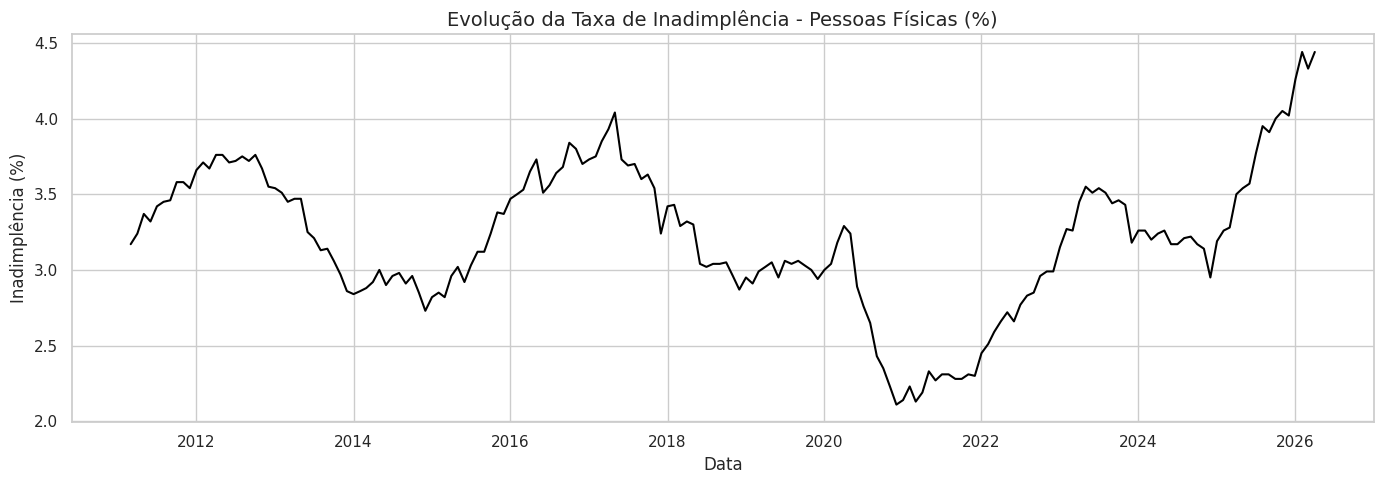

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Inadimplencia_PF'], color='black', linewidth=1.5)
plt.title('Evolução da Taxa de Inadimplência - Pessoas Físicas (%)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Inadimplência (%)')
plt.tight_layout()
plt.show()

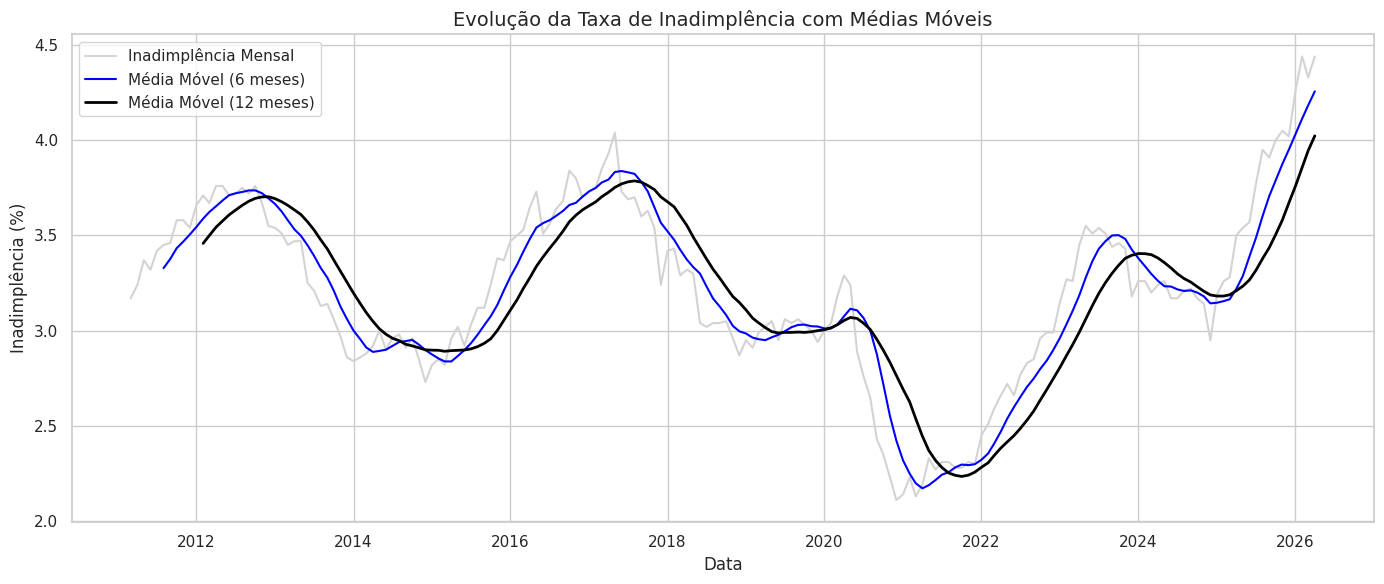

In [ ]:
# Calculando a média móvel de 6 e 12 meses
df['Inad_MM6'] = df['Inadimplencia_PF'].rolling(window=6).mean()
df['Inad_MM12'] = df['Inadimplencia_PF'].rolling(window=12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Inadimplencia_PF'], color='lightgray', label='Inadimplência Mensal')
plt.plot(df.index, df['Inad_MM6'], color='blue', label='Média Móvel (6 meses)')
plt.plot(df.index, df['Inad_MM12'], color='black', linewidth=2, label='Média Móvel (12 meses)')
plt.title('Evolução da Taxa de Inadimplência com Médias Móveis', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Inadimplência (%)')
plt.legend()
plt.tight_layout()
plt.show()

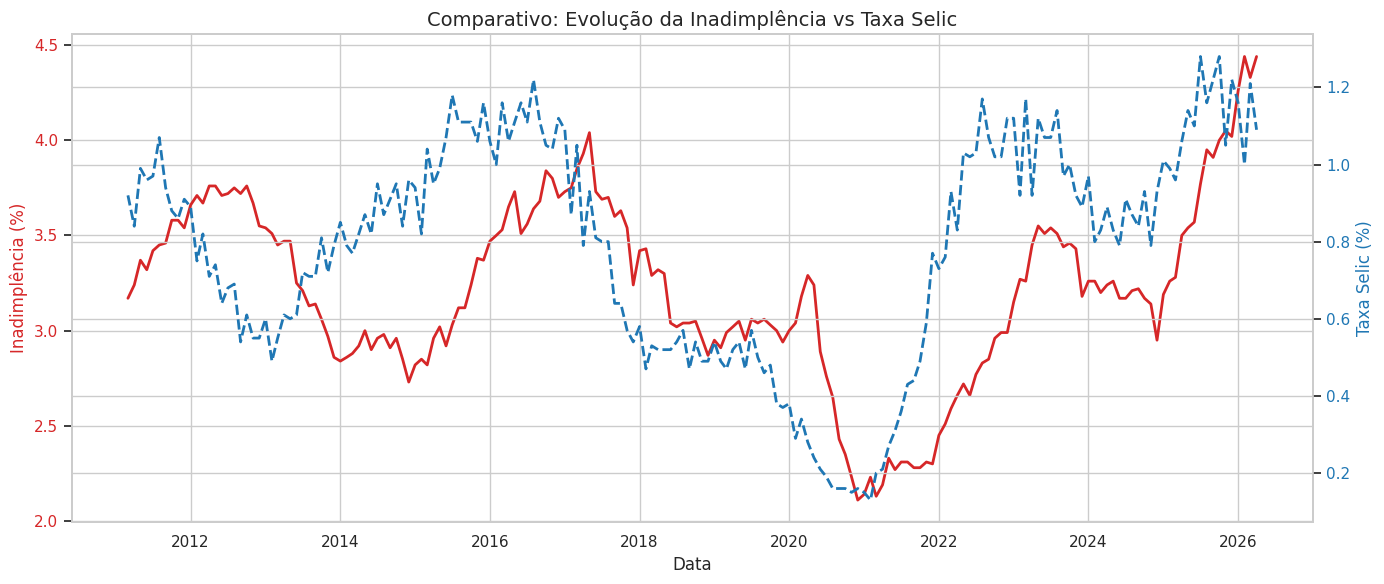

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo Y esquerdo: Inadimplência
color1 = 'tab:red'
ax1.set_xlabel('Data')
ax1.set_ylabel('Inadimplência (%)', color=color1)
ax1.plot(df.index, df['Inadimplencia_PF'], color=color1, linewidth=2, label='Inadimplência PF')
ax1.tick_params(axis='y', labelcolor=color1)

# Eixo Y direito: Selic (compartilhando o mesmo eixo X)
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Taxa Selic (%)', color=color2)
ax2.plot(df.index, df['Selic'], color=color2, linewidth=2, linestyle='--', label='Selic')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Comparativo: Evolução da Inadimplência vs Taxa Selic', fontsize=14)
fig.tight_layout()
plt.show()

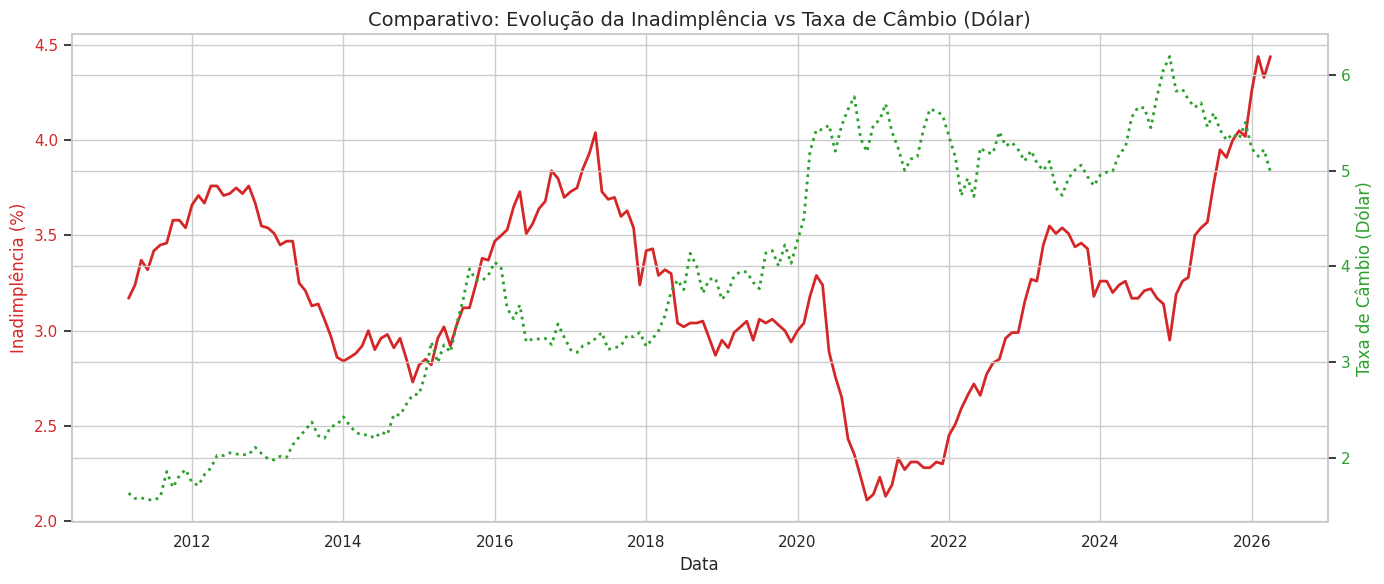

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo Y esquerdo: Inadimplência
color_inad = 'tab:red'
ax1.set_xlabel('Data')
ax1.set_ylabel('Inadimplência (%)', color=color_inad)
ax1.plot(df.index, df['Inadimplencia_PF'], color=color_inad, linewidth=2, label='Inadimplência PF')
ax1.tick_params(axis='y', labelcolor=color_inad)

# Eixo Y direito: Dólar
ax2 = ax1.twinx()
color_dolar = 'tab:green'
ax2.set_ylabel('Taxa de Câmbio (Dólar)', color=color_dolar)
ax2.plot(df.index, df['Dolar'], color=color_dolar, linewidth=2, linestyle=':', label='Dólar')
ax2.tick_params(axis='y', labelcolor=color_dolar)

plt.title('Comparativo: Evolução da Inadimplência vs Taxa de Câmbio (Dólar)', fontsize=14)
fig.tight_layout()
plt.show()

A observação da série histórica da inadimplência das pessoas físicas, suavizada pelas médias móveis de 6 e 12 meses, revela uma forte característica cíclica associada aos movimentos macroeconômicos do Brasil na última década. O uso da média móvel de 12 meses (linha preta) é particularmente útil para remover o ruído mensal e evidenciar a tendência de longo prazo. Além disso, o cruzamento visual com a taxa de câmbio (Dólar) fornece uma camada extra de contexto sobre o grau de estresse econômico do país em cada ciclo.

Destacam-se os seguintes períodos na série:

- **A escalada da crise (2015 - 2017):** Após um período de baixa até 2014, a inadimplência sofre uma forte aceleração culminando em um pico entre 2016 e 2017. Este movimento reflete a severa recessão econômica do período, caracterizada por alta inflação, aumento expressivo do desemprego e elevação da taxa de juros (Selic). Neste mesmo intervalo, o gráfico revela uma disparada paralela do Dólar (saindo da faixa de R$ 2,50 para quase R$ 4,00), evidenciando a perda de grau de investimento do país, a forte desvalorização do Real e uma pressão inflacionária que asfixiou rapidamente o orçamento das famílias.

- **Recuperação gradual (2018 - início de 2020):** Nota-se uma tendência de queda consistente ("desalavancagem" das famílias), impulsionada por um cenário de controle inflacionário e a progressiva redução da taxa Selic, que atingiria suas mínimas históricas. O Dólar, embora mais alto, apresentou certa estabilização direcional nesse período, permitindo um respiro na inflação.

- **O choque da Pandemia (2020 - 2021):** Observa-se uma "queda surreal" e atípica na taxa de inadimplência em 2020/2021. Esse fenômeno contraintuitivo (esperava-se aumento na crise sanitária) é explicado por intervenções governamentais, como a injeção de liquidez via Auxílio Emergencial, e pelas políticas temporárias de prorrogação e renegociação de dívidas adotadas pelos bancos comerciais. Visualmente, ocorre uma notável quebra de padrão (descorrelação) neste momento: enquanto o Dólar sofre um novo e abrupto choque de alta devido ao pânico global e fuga de capital (ultrapassando os R$ 5,00), a inadimplência afunda, mascarada momentaneamente pelas injeções de liquidez.

- **A ressaca inflacionária e o pico recente (2022 - 2026):** Passado o efeito dos auxílios, a série retoma uma escalada agressiva até 2024. A leve queda observada em 2025 é rapidamente revertida, atingindo o pico máximo da série histórica em 2026. Este comportamento sugere o esgotamento da capacidade de pagamento das famílias frente a um cenário prolongado de restrição de crédito e o efeito defasado de juros altos acumulados nos anos anteriores. O câmbio, consolidado e sustentando-se em patamares historicamente elevados ao longo de todo esse ciclo pós-pandemia, atua como um vetor constante de inflação (encarecendo combustíveis, alimentos e importados), o que corrói o poder de compra e dificulta qualquer tentativa de recuperação financeira sustentável da pessoa física.

## Decompondo a Série

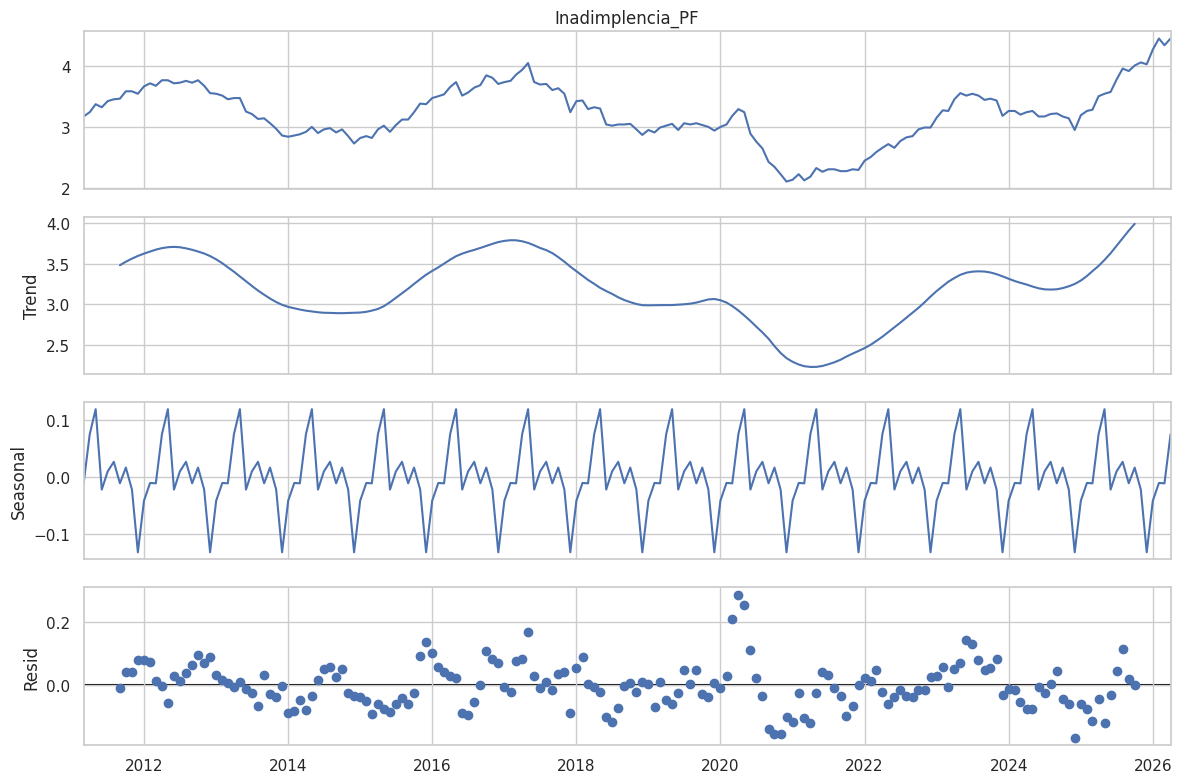

In [ ]:
# Decomposição usando o modelo aditivo e período de 12 meses
decomposicao = seasonal_decompose(df['Inadimplencia_PF'], model='additive', period=12)

fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

Note como a tendência confirma o ciclo macroeconômico que ditado anteriormente. Há uma desalavancagem (queda) contínua de 2013 até meados de 2015. A crise de 2016 gera uma rampa de subida íngreme. O período pós-crise (2018-2020) mostra uma estabilização seguida de queda. Em 2021 ocorre o vale (mínima histórica da tendência devido aos auxílios e renegociações da pandemia) e, a partir dali, uma inversão brutal de tendência com crescimento contínuo, atingindo o ápice em 2026. Conclusão estatística: A inadimplência no Brasil é **fortemente ditada por ciclos estruturais da economia, e não por eventos passageiros**.

Quando olhamos para a sazonalidade, temos um padrão repetitivo entre os mesmos limites. Isso prova matematicamente que existe sazonalidade na inadimplência. Significa que, independentemente de a economia estar indo bem ou mal, existem meses específicos do ano em que a inadimplência sempre tende a subir e outros em que sempre tende a cair.

Por fim, analisando os resíduos, vemos um comportamento anômalo por volta de 2020 e 2021. Há oscilações muito bruscas (picos para cima e para baixo). Conclu-se que esse comportamento isola perfeitamente o "efeito choque" provocado pela pandemia da COVID-19. Foi um evento exógeno tão fora da curva que nem a tendência suave e nem a sazonalidade anual conseguiram explicar, transbordando para o resíduo.

## Estudo do Comportamento Sazonal - BoxPlots

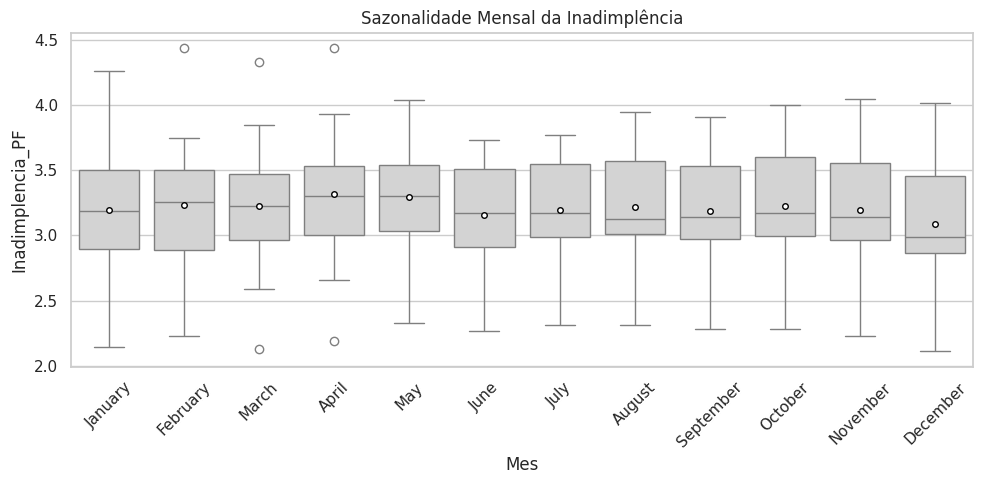

In [ ]:
# Extraindo o mês do índice temporal
df['Mes'] = df.index.month_name()
ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(10,5))
sns.boxplot(x="Mes", y="Inadimplencia_PF", data=df, order=ordem_meses, color="lightgrey",
            linewidth=1.0, width=0.8, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white",
                       "markeredgecolor":"black", "markersize":"4"})
plt.title("Sazonalidade Mensal da Inadimplência", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Extraindo o nome do mês a partir do DatetimeIndex e definindo a ordem categórica
ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Criando a coluna 'Mes' baseada no índice
df['Mes'] = pd.Categorical(df.index.month_name(), categories=ordem_meses, ordered=True)

# Calculando as estatísticas descritivas
estatisticas_mensais = df.groupby('Mes', observed=False)['Inadimplencia_PF'].describe()

# Exibindo o resultado formatado em Markdown
from IPython.display import Markdown
display(Markdown(estatisticas_mensais.round(3).to_markdown()))

| Mes       |   count |   mean |   std |   min |   25% |   50% |   75% |   max |
|:----------|--------:|-------:|------:|------:|------:|------:|------:|------:|
| January   |      15 |  3.192 | 0.529 |  2.14 | 2.895 | 3.19  | 3.505 |  4.26 |
| February  |      15 |  3.235 | 0.541 |  2.23 | 2.885 | 3.26  | 3.505 |  4.44 |
| March     |      16 |  3.226 | 0.51  |  2.13 | 2.963 | 3.23  | 3.47  |  4.33 |
| April     |      16 |  3.315 | 0.523 |  2.19 | 3.005 | 3.305 | 3.538 |  4.44 |
| May       |      15 |  3.292 | 0.432 |  2.33 | 3.035 | 3.3   | 3.545 |  4.04 |
| June      |      15 |  3.16  | 0.412 |  2.27 | 2.91  | 3.17  | 3.51  |  3.73 |
| July      |      15 |  3.199 | 0.417 |  2.31 | 2.99  | 3.17  | 3.55  |  3.77 |
| August    |      15 |  3.221 | 0.447 |  2.31 | 3.01  | 3.13  | 3.575 |  3.95 |
| September |      15 |  3.191 | 0.462 |  2.28 | 2.975 | 3.14  | 3.53  |  3.91 |
| October   |      15 |  3.225 | 0.501 |  2.28 | 2.995 | 3.17  | 3.605 |  4    |
| November  |      15 |  3.193 | 0.514 |  2.23 | 2.965 | 3.14  | 3.56  |  4.05 |
| December  |      15 |  3.09  | 0.509 |  2.11 | 2.865 | 2.99  | 3.455 |  4.02 |

1. **O Ciclo de Pressão e o Ápice da "Ressaca" Financeira**: Observa-se que a escalada da inadimplência se inicia nos primeiros meses do ano e atinge suas maiores médias absolutas no fechamento do primeiro quadrimestre, especificamente em Abril (3.31%) e Maio (3.29%). Esse movimento, estatisticamente consolidado, documenta a "ressaca" financeira: o acúmulo de despesas sazonais (IPVA, IPTU, material escolar) comprime a renda das famílias no início do ano, levando ao esgotamento do orçamento e ao pico de calotes nos meses imediatamente subsequentes.

2. **O Alívio de Dezembro (Injeção de Liquidez)**: Em contrapartida, Dezembro consolida-se como o mês de maior alívio, registrando a menor média (3.09%), a menor mediana (2.99%) e o menor valor mínimo da série histórica (2.11%). Isso sugere um forte e consistente efeito da injeção do 13º salário na economia, permitindo às famílias regularizarem suas dívidas correntes no encerramento do exercício.

3. **Variabilidade e Suscetibilidade a Choques**: Os primeiros meses do ano não só abrigam médias maiores, como também apresentam os maiores desvios padrão (std de 0.54 em Fevereiro e 0.52 em Abril) e os valores máximos absolutos da série (4.44%). Isso indica que, em anos de crise macroeconômica, a inadimplência explode com muito mais força e volatilidade no primeiro quadrimestre do que no restante do ano.

4. **Consistência Central (Ancoragem)**: Apesar dos picos de estresse, a mediana (50%) mantém-se próxima da faixa de 3.1% a 3.2% ao longo da maior parte do ano. Isso reforça que a série possui uma ancoragem estrutural de longo prazo, mas responde com extrema sensibilidade aos choques de liquidez ditados pelo calendário anual.

Conclui-se que
a análise descritiva confirma numericamente a existência de uma sazonalidade clara: um estrangulamento orçamentário no primeiro semestre (com ápice em Abril/Maio) e uma vigorosa recuperação por injeção de liquidez extra no final do ano.

## Correlacoes

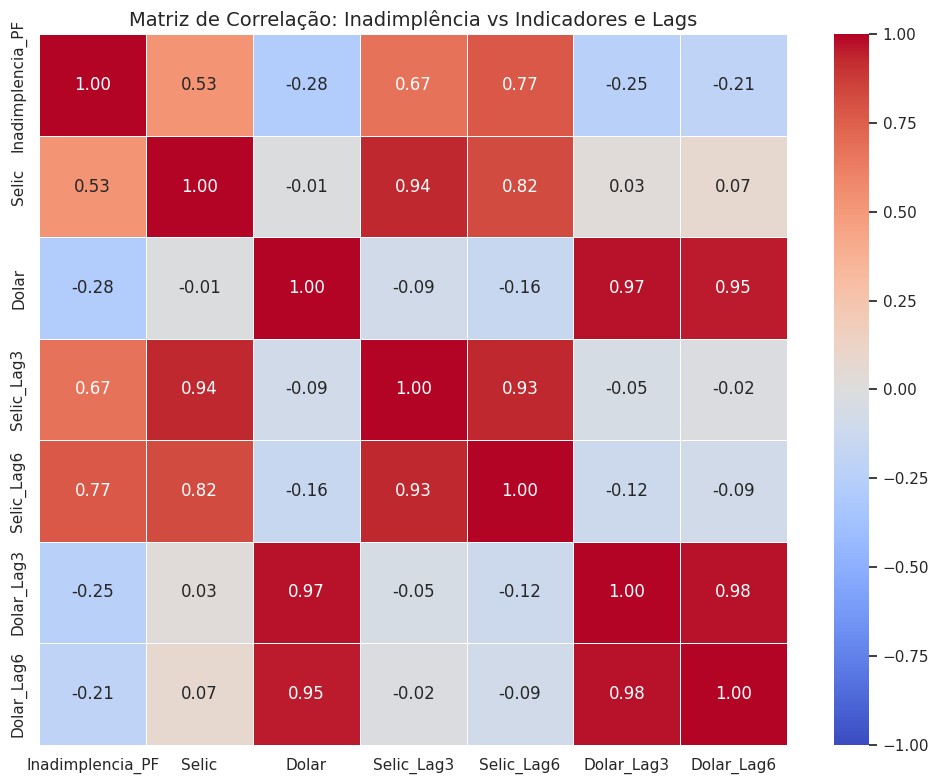

In [ ]:
# Criando um DataFrame apenas com as colunas financeiras
df_econ = df[['Inadimplencia_PF', 'Selic', 'Dolar']].copy()

# Criando defasagens (lags) de 3 e 6 meses
df_econ['Selic_Lag3'] = df_econ['Selic'].shift(3)
df_econ['Selic_Lag6'] = df_econ['Selic'].shift(6)
df_econ['Dolar_Lag3'] = df_econ['Dolar'].shift(3)
df_econ['Dolar_Lag6'] = df_econ['Dolar'].shift(6)

# Removendo os NaNs gerados pelo shift
df_econ = df_econ.dropna()

# Calculando a matriz de correlação de Pearson
matriz_corr = df_econ.corr()

# Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação: Inadimplência vs Indicadores e Lags', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
matriz_corr = df_econ.corr()

tabela_corr = matriz_corr[['Inadimplencia_PF']].sort_values(by='Inadimplencia_PF', ascending=False)

display(tabela_corr.round(3))

,Inadimplencia_PF
Inadimplencia_PF,1.000
Selic_Lag6,0.774
Selic_Lag3,0.673
Selic,0.527
Dolar_Lag6,-0.211
Dolar_Lag3,-0.249
Dolar,-0.282


O estudo da matriz de correlação cruzando a Inadimplência da Pessoa Física com indicadores macroeconômicos (Selic e Dólar), acrescido de defasagens temporais (lags de 3 e 6 meses), revela insights fundamentais sobre a dinâmica do endividamento no Brasil:

1. **A Forte Sensibilidade à Taxa de Juros (Selic)**:
Existe uma correlação positiva e direta entre a taxa básica de juros e a inadimplência, comprovando que o encarecimento do crédito é o principal motor do calote no varejo.

2. **O Efeito de Transmissão Defasado (O "Lag" de 6 meses)**:
O achado mais expressivo da análise recai sobre o comportamento temporal dessa correlação. A inadimplência possui uma correlação moderada com a Selic do mês corrente ($r = 0.527$). Contudo, essa força explicativa cresce significativamente ao aplicarmos defasagens de 3 meses ($r = 0.673$) e atinge seu ápice de correlação forte na defasagem de 6 meses ($r = 0.774$ para Selic_Lag6).

**Conclusão**: A política monetária possui um efeito de transmissão lento para o mercado de crédito físico. Quando o Banco Central eleva os juros, as famílias tendem a sustentar o pagamento de suas dívidas utilizando reservas ou rearranjos orçamentários por um período. O esgotamento financeiro e a consequente explosão da inadimplência refletem, com maior precisão, o cenário de juros de um semestre atrás.

3. **A Baixa Relevância do Câmbio (Dólar)**:
As correlações matemáticas lineares com a taxa de câmbio apresentaram-se fracas e inversas ($r$ entre -0.211 e -0.282). Isso comprova que não há um efeito imediato do tipo "dólar sobe, calote sobe". Diferentemente do endividamento corporativo (que possui dívidas em moeda estrangeira), a Pessoa Física é imune a choques cambiais de curto prazo no seu carnê ou fatura. Contudo, conforme observado na análise histórica, o Dólar atua de forma estrutural e indireta: sua alta pressiona a inflação, que por sua vez obriga o Banco Central a elevar a Selic. A matemática confirma, portanto, que a taxa de juros (Selic) é a verdadeira e única transmissora direta da crise cambial e inflacionária para a inadimplência do varejo.

## ACF e PACF

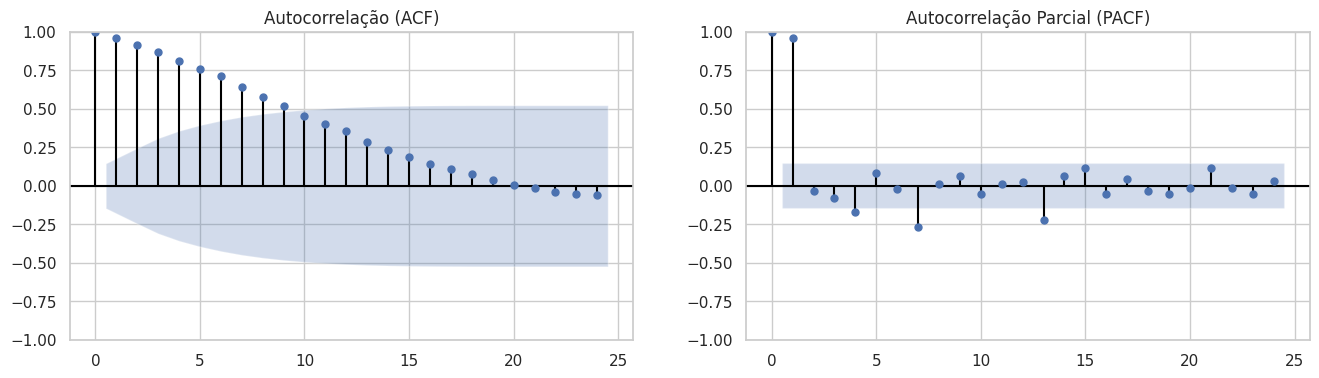

--- Teste Dickey-Fuller Aumentado (ADF) ---
Estatística do Teste: -2.0337
P-value: 0.2720
Conclusão: A série é NÃO-ESTACIONÁRIA (possui tendência).


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# 1. Plots de Autocorrelação
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Inadimplencia_PF'].dropna(), lags=24, ax=axes[0], title='Autocorrelação (ACF)')
plot_pacf(df['Inadimplencia_PF'].dropna(), lags=24, ax=axes[1], title='Autocorrelação Parcial (PACF)')
plt.show()

# 2. Teste de Estacionariedade (Augmented Dickey-Fuller)
resultado_adf = adfuller(df['Inadimplencia_PF'].dropna())
print("--- Teste Dickey-Fuller Aumentado (ADF) ---")
print(f"Estatística do Teste: {resultado_adf[0]:.4f}")
print(f"P-value: {resultado_adf[1]:.4f}")
if resultado_adf[1] < 0.05:
    print("Conclusão: A série é ESTACIONÁRIA (rejeitamos a hipótese nula).")
else:
    print("Conclusão: A série é NÃO-ESTACIONÁRIA (possui tendência).")

Antes de prosseguirmos para a modelagem preditiva, vamos analisar as propriedades matemáticas da série em seu estado original (bruto). Essa etapa serve como um diagnóstico para entender o comportamento natural da inadimplência e justificar as transformações matemáticas que serão necessárias a seguir.

1. Estrutura de Autocorrelação (Diagnóstico Visual): Ao plotarmos os correlogramas da série original, observamos um decaimento progressivo e muito lento no gráfico ACF (Autocorrelação). Estatisticamente, este é um sintoma clássico de séries não-estacionárias (com tendência). Economicamente, isso indica que a série de inadimplência possui longa memória temporal, refletindo o fato de que estoques de dívida não se liquidam rapidamente no varejo. Paralelamente, o PACF (Autocorrelação Parcial) exibe um forte pico no primeiro lag (defasagem). Isso traduz numericamente a forte inércia da inadimplência no mundo real: o nível de atrasos do mês atual é altamente dependente e explicado pelo patamar do mês imediatamente anterior.

2. Confirmação do Teste ADF (Diagnóstico Estatístico): A impressão visual deixada pelo ACF foi confirmada matematicamente pelo Teste Aumentado de Dickey-Fuller. A aplicação do teste resultou em uma estatística de -2.0337 e um p-valor de 0.2720. Como o p-valor é significativamente maior que o nível de significância padrão (0.05), não podemos rejeitar a hipótese nula. Isso comprova estatisticamente que a série é Não-Estacionária. Fica provado que a média e a variância da inadimplência não são constantes ao longo do tempo, sendo ditadas por quebras estruturais e fortes tendências de longo prazo.

3. O Porquê da Diferenciação (A Ponte para a Modelagem): Esta constatação matemática de não-estacionariedade é crucial por dois motivos principais:

Para evitar relações falsas: Se cruzássemos diretamente os valores brutos da inadimplência com indicadores como a Selic ou o Dólar (que também possuem tendências próprias) em modelos lineares (como Regressão ou VAR), geraríamos "correlações espúrias" — o modelo acharia que um causa o outro apenas porque ambos crescem com o passar do tempo.

Para viabilizar o ARIMA: Modelos preditivos autorregressivos exigem que a série seja estacionária (sem tendência) para calibrar suas previsões corretamente.

Portanto, este diagnóstico deixa documentado que, para avançar com a modelagem matemática de forma rigorosa, foi obrigatório aplicar a diferenciação na série (transformando os valores absolutos em variações mês a mês). Ao diferenciar a série (o parâmetro d do modelo ARIMA), nós removemos a tendência e pudemos gerar um novo conjunto de gráficos ACF e PACF, agora estacionários, para identificar os verdadeiros parâmetros de atraso (p e q) necessários para treinar o algoritmo preditivo.

## Diferenciação

--- Teste ADF na Série Diferenciada ---
Estatística do Teste: -2.9925
P-value: 0.0356


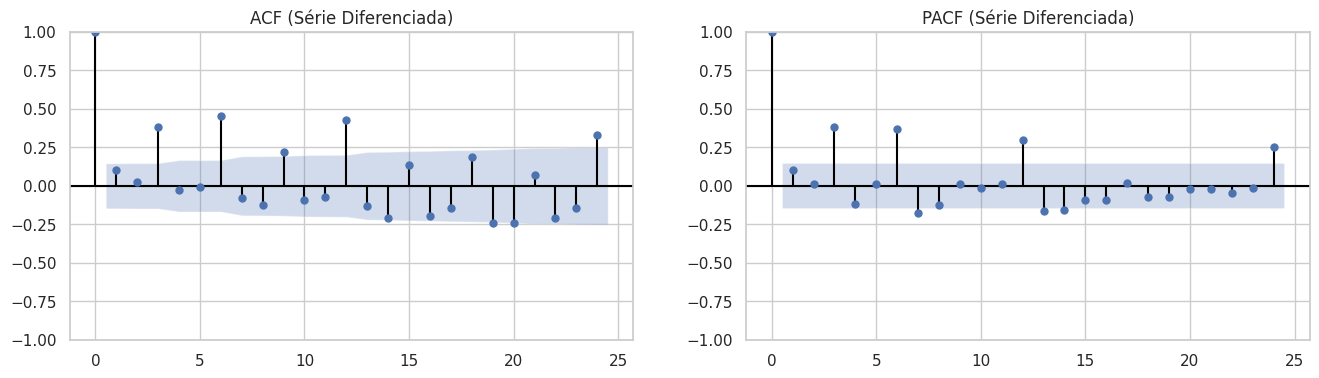

In [ ]:
# 1. Aplicando a Diferenciação (d=1) para remover a tendência
df['Inad_Diff'] = df['Inadimplencia_PF'].diff().dropna()

# 2. Validando se agora ficou Estacionária com um novo teste ADF
resultado_adf_diff = adfuller(df['Inad_Diff'].dropna())
print("--- Teste ADF na Série Diferenciada ---")
print(f"Estatística do Teste: {resultado_adf_diff[0]:.4f}")
print(f"P-value: {resultado_adf_diff[1]:.4f}")

# 3. Plotando ACF e PACF da série diferenciada para achar 'p' e 'q'
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Inad_Diff'].dropna(), lags=24, ax=axes[0], title='ACF (Série Diferenciada)')
plot_pacf(df['Inad_Diff'].dropna(), lags=24, ax=axes[1], title='PACF (Série Diferenciada)')
plt.show()

## ARIMA e Forecast

                               SARIMAX Results                                
Dep. Variable:       Inadimplencia_PF   No. Observations:                  182
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 163.678
Date:                Sat, 06 Jun 2026   AIC                           -321.356
Time:                        14:57:50   BIC                           -311.760
Sample:                    03-01-2011   HQIC                          -317.465
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8871      0.113      7.834      0.000       0.665       1.109
ma.L1         -0.7780      0.148     -5.241      0.000      -1.069      -0.487
sigma2         0.0096      0.001     12.332      0.0

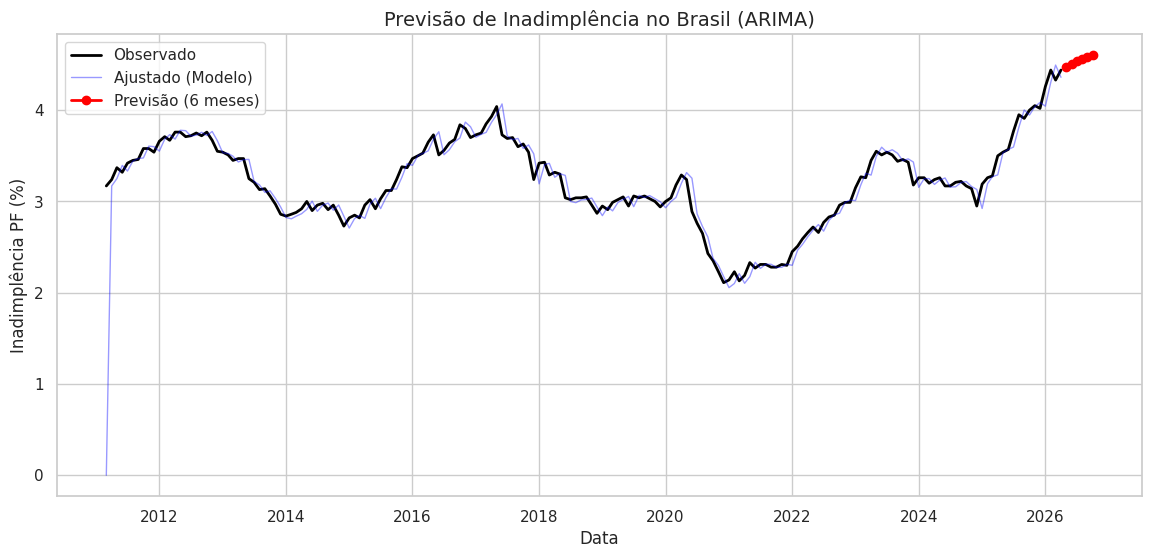

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Vamos começar com um modelo ARIMA(1, 1, 1) como base.
# (Dependendo do gráfico da Etapa 1, podemos ajustar isso depois!)
modelo = ARIMA(df['Inadimplencia_PF'], order=(1, 1, 1))
model_fit = modelo.fit()

# Imprime a análise estatística do modelo
print(model_fit.summary())

# Forecast para os próximos 6 meses
forecast_steps = 6
forecast = model_fit.get_forecast(steps=forecast_steps)
predictions = forecast.predicted_mean

# Criando o gráfico final
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Inadimplencia_PF'], label="Observado", color='black', lw=2)

# O Fitted Values é o que o modelo "aprendeu" do passado
plt.plot(model_fit.fittedvalues.index, model_fit.fittedvalues, label="Ajustado (Modelo)", color="blue", alpha=0.4, lw=1)

# O Forecast é a previsão real para o futuro
plt.plot(predictions.index, predictions, label="Previsão (6 meses)", marker="o", color="red", lw=2)

plt.xlabel("Data")
plt.ylabel("Inadimplência PF (%)")
plt.legend()
plt.title("Previsão de Inadimplência no Brasil (ARIMA)", fontsize=14)
plt.show()

Para consolidar as análises estatísticas e avaliar o cenário futuro da inadimplência, foi desenvolvido um modelo ARIMA.

Como o diagnóstico anterior provou a não-estacionariedade da série original, aplicou-se a diferenciação de primeira ordem (d=1). O novo Teste Dickey-Fuller (ADF) na série diferenciada resultou em um p-valor de 0.0356 (menor que o nível de significância de 0.05), atestando que a série de variações mensais tornou-se rigorosamente estacionária, requisito essencial para a modelagem.

Com base na análise dos correlogramas da série diferenciada, ajustou-se um modelo ARIMA(1, 1, 1). A tabela de resultados (Summary) indica um ajuste excelente:

- **Coeficientes Significativos:** Tanto a componente Autorregressiva quanto a componente de Médias Móveis são estatisticamente significativas. Isso significa que o modelo conseguiu capturar com sucesso tanto a inércia do mês anterior quanto o ajuste a choques imprevistos recentes.

- **Resíduos bem comportados:** O teste de Ljung-Box (Prob(Q) = 0.47) atesta que não sobrou autocorrelação nos resíduos. Ou seja, o modelo conseguiu extrair todo o padrão matemático da série, restando apenas "ruído branco" aleatório.


Ao projetar (Forecast) a inadimplência para os próximos 6 meses, o modelo sinaliza uma tendência matemática de alta contínua.
Essa projeção estatística é perfeitamente coerente com o cenário macroeconômico descoberto na análise de correlações. Como comprovamos que o ciclo de alta da Taxa Selic possui um efeito de transmissão defasado de cerca de 6 meses (Selic_Lag6), o encarecimento do crédito acumulado no semestre anterior continuará pressionando e asfixiando o orçamento das famílias, justificando a continuidade da escalada da curva de inadimplência projetada pelo modelo ARIMA para o futuro imediato.